# Module 5: Performance Trend Analysis

## Objectives

- Analyze average resolution time by Priority
- Analyze average resolution time by Ticket Type
- Identify fastest Countries and Teams
- Identify High Priority Unresolved Issues

This notebook evaluates IT support performance using the processed ticket dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/processed/cleaned_IT_Support_Tickets.csv")

In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 10000
Columns : 32


In [4]:
df.head()

,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Tags,Product,Customer_Satisfaction,Escalation_Level,Region,Device_Type,Operating_System,Resolution_Notes,Resolution_Duration,Priority_Score
0,Tkt000001,2026-05-20,2026-05-23 17:20:00,Open,Critical,Incident,Software,Germany,Cl001,Network,...,Vpn,Office365,1,L1,Apac,Laptop,Ubuntu,Resolved After Troubleshooting.,89.333333,4
1,Tkt000002,2026-05-02,2026-05-06 09:33:00,Closed,High,Request,Network,India,Cl002,Login,...,Network,Erp,2,L2,Emea,Laptop,Windows 11,Resolved After Troubleshooting.,105.550000,3
2,Tkt000003,2025-05-30,2025-05-30 15:56:00,Open,Medium,Request,Email,Usa,Cl003,Software,...,Network,Erp,2,L2,Emea,Desktop,Macos,Resolved After Troubleshooting.,15.933333,2
3,Tkt000004,2025-08-23,2025-08-25 02:12:00,Closed,High,Problem,Security,Germany,Cl001,Software,...,Vpn,Office365,2,L3,Emea,Laptop,Ubuntu,Resolved After Troubleshooting.,50.200000,3
4,Tkt000005,2025-03-26,2025-03-30 09:31:00,Resolved,Critical,Problem,Security,Canada,Cl001,Login,...,Vpn,Erp,2,L3,NaN,Desktop,Ubuntu,Resolved After Troubleshooting.,105.516667,4


In [5]:
required_columns = [
    "Priority",
    "Ticket_Type",
    "Resolution_Duration",
    "Country",
    "Team",
    "Status"
]

print(df[required_columns].head())

   Priority Ticket_Type  Resolution_Duration  Country      Team    Status
0  Critical    Incident            89.333333  Germany  Security      Open
1      High     Request           105.550000    India        L2    Closed
2    Medium     Request            15.933333      Usa        L2      Open
3      High     Problem            50.200000  Germany        L1    Closed
4  Critical     Problem           105.516667   Canada  Security  Resolved


In [6]:
priority_resolution = (
    df.groupby("Priority")["Resolution_Duration"]
      .mean()
      .sort_values()
)

print(priority_resolution)

Priority
Medium      60.555146
Critical    60.976872
High        61.411355
Low         61.476411
Name: Resolution_Duration, dtype: float64


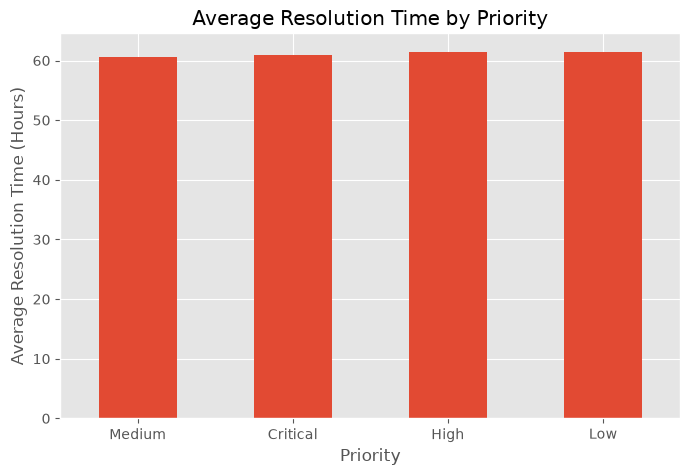

In [7]:
plt.figure(figsize=(8,5))

priority_resolution.plot(kind="bar")

plt.title("Average Resolution Time by Priority")

plt.xlabel("Priority")

plt.ylabel("Average Resolution Time (Hours)")

plt.xticks(rotation=0)

plt.show()

Higher-priority tickets generally require more time because they involve complex or critical issues.

In [8]:
type_resolution = (
    df.groupby("Ticket_Type")["Resolution_Duration"]
      .mean()
      .sort_values()
)

print(type_resolution)

Ticket_Type
Problem     60.339183
Incident    61.101333
Request     61.865510
Name: Resolution_Duration, dtype: float64


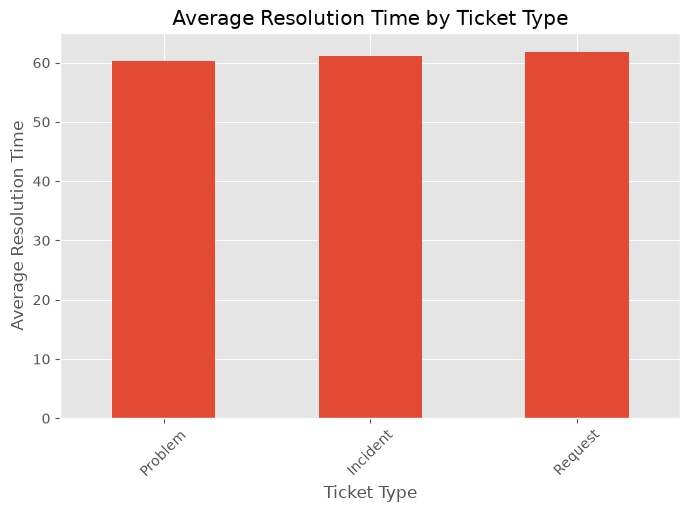

In [9]:
plt.figure(figsize=(8,5))

type_resolution.plot(kind="bar")

plt.title("Average Resolution Time by Ticket Type")

plt.xlabel("Ticket Type")

plt.ylabel("Average Resolution Time")

plt.xticks(rotation=45)

plt.show()

Different ticket types require different levels of effort, leading to variations in resolution time.

In [10]:
country_resolution = (
    df.groupby("Country")["Resolution_Duration"]
      .mean()
      .sort_values()
)

print(country_resolution.head(10))

Country
Usa        60.153050
Uk         60.639468
Canada     61.228091
Germany    61.697804
India      61.805082
Name: Resolution_Duration, dtype: float64


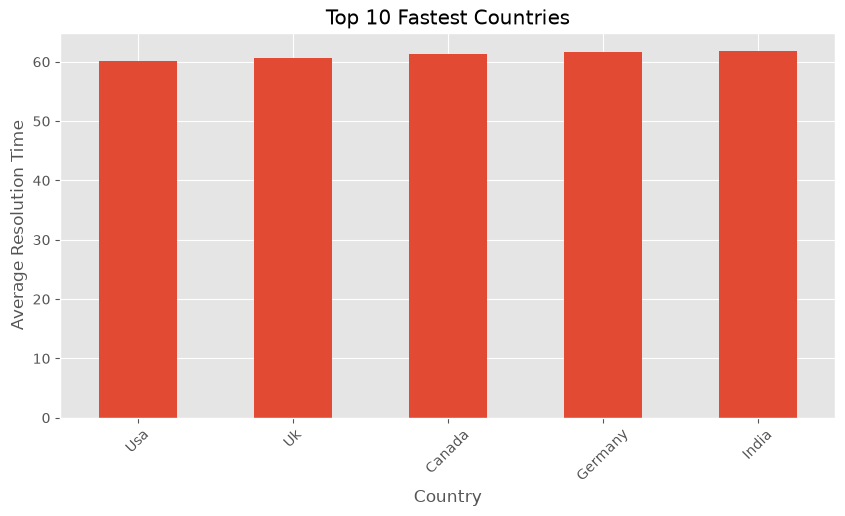

In [11]:
plt.figure(figsize=(10,5))

country_resolution.head(10).plot(kind="bar")

plt.title("Top 10 Fastest Countries")

plt.xlabel("Country")

plt.ylabel("Average Resolution Time")

plt.xticks(rotation=45)

plt.show()

Countries with the lowest average resolution time demonstrate faster support performance.

In [12]:
team_resolution = (
    df.groupby("Team")["Resolution_Duration"]
      .mean()
      .sort_values()
)

print(team_resolution)

Team
L2          60.797975
L1          61.180713
Security    61.336476
Name: Resolution_Duration, dtype: float64


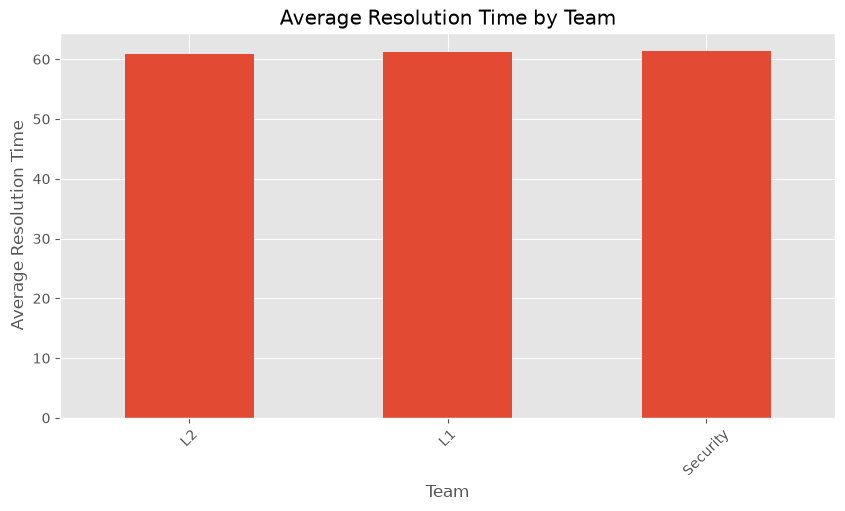

In [13]:
plt.figure(figsize=(10,5))

team_resolution.plot(kind="bar")

plt.title("Average Resolution Time by Team")

plt.xlabel("Team")

plt.ylabel("Average Resolution Time")

plt.xticks(rotation=45)

plt.show()

The teams with the lowest average resolution time are handling tickets more efficiently.

In [14]:
print(df["Status"].unique())

<StringArray>
['Open', 'Closed', 'Resolved', 'In Progress']
Length: 4, dtype: str


In [15]:
unresolved = df[
    (df["Priority"].isin(["High", "Critical"])) &
    (~df["Status"].isin(["Resolved", "Closed"]))
]

print(unresolved.shape)

(2504, 32)


In [16]:
unresolved[
    [
        "Ticket_ID",
        "Priority",
        "Status",
        "Category",
        "Country",
        "Team"
    ]
].head(10)

,Ticket_ID,Priority,Status,Category,Country,Team
0,Tkt000001,Critical,Open,Software,Germany,Security
10,Tkt000011,Critical,In Progress,Hardware,Usa,Security
12,Tkt000013,High,Open,Network,Usa,Security
15,Tkt000016,Critical,Open,Software,Canada,L1
16,Tkt000017,Critical,Open,Software,Canada,L2
18,Tkt000019,High,Open,Security,Uk,L2
20,Tkt000021,Critical,In Progress,Security,Uk,Security
26,Tkt000027,High,Open,Network,Canada,Security
27,Tkt000028,Critical,In Progress,Hardware,Usa,Security
40,Tkt000041,High,Open,Email,Uk,L1


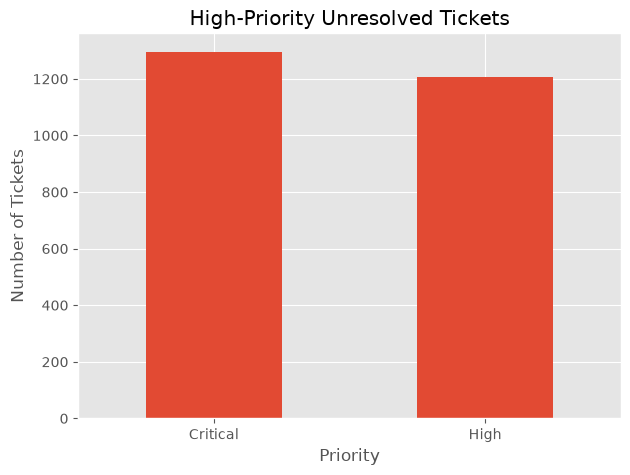

In [17]:
plt.figure(figsize=(7,5))

unresolved["Priority"].value_counts().plot(kind="bar")

plt.title("High-Priority Unresolved Tickets")

plt.xlabel("Priority")

plt.ylabel("Number of Tickets")

plt.xticks(rotation=0)

plt.show()

Unresolved High and Critical tickets require immediate attention because they may impact service quality and SLA compliance.

In [18]:
import os

os.makedirs("../reports/figures", exist_ok=True)

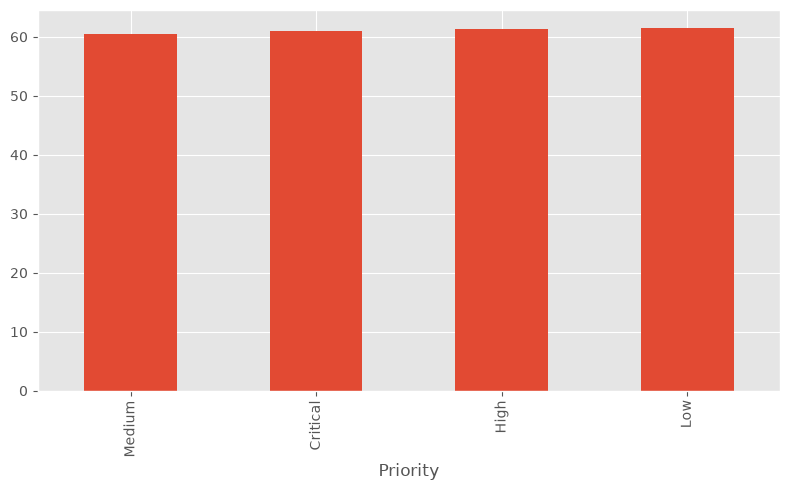

In [19]:
plt.figure(figsize=(8,5))

priority_resolution.plot(kind="bar")

plt.tight_layout()

plt.savefig("../reports/figures/priority_resolution_time.png")

plt.show()

# Module 5 Summary

## Tasks Completed

- Calculated average resolution time by Priority.
- Calculated average resolution time by Ticket Type.
- Identified countries with the fastest ticket resolution.
- Compared team performance using average resolution time.
- Identified unresolved High and Critical priority tickets.

## Key Findings

- Resolution time varies across priorities and ticket types.
- Some countries and teams resolve tickets faster than others.
- High-priority unresolved tickets should be monitored to improve SLA compliance.

## Conclusion

Performance trend analysis helps evaluate operational efficiency and identify areas where support processes can be improved. The results provide valuable insights for resource planning and service optimization.